In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import itertools
import numpy as np
import holidays

c:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = pd.read_csv("C:/Users/alexa/OneDrive/Documentos/Curso5/Proyectos4/casa_5_clima.csv", parse_dates=True)
df = df.drop(columns=['fecha'])

df.rename(columns={'consumo_kWh': 'y', 'timestamp': 'ds'}, inplace=True)

# Exploración de Variables del Dataset
En esta sección, exploraremos las variables disponibles en el dataset para determinar cuáles son útiles para el modelo Prophet.

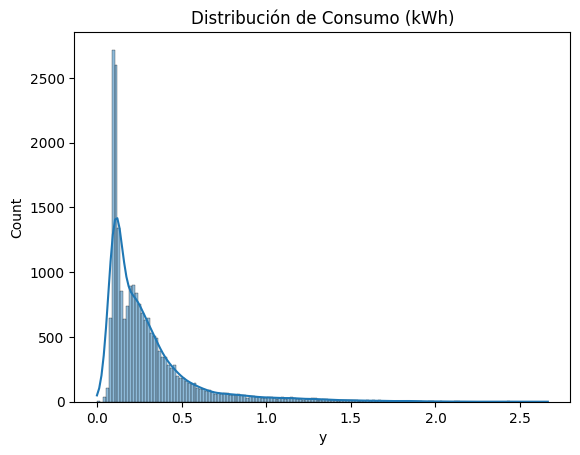

In [ ]:
sns.histplot(df['y'], kde=True)
plt.title('Distribución de Consumo (kWh)')
plt.show()

# Análisis de Relaciones entre Variables
En esta sección, analizaremos las relaciones entre las variables del dataset para identificar cuáles son relevantes para el modelo Prophet.

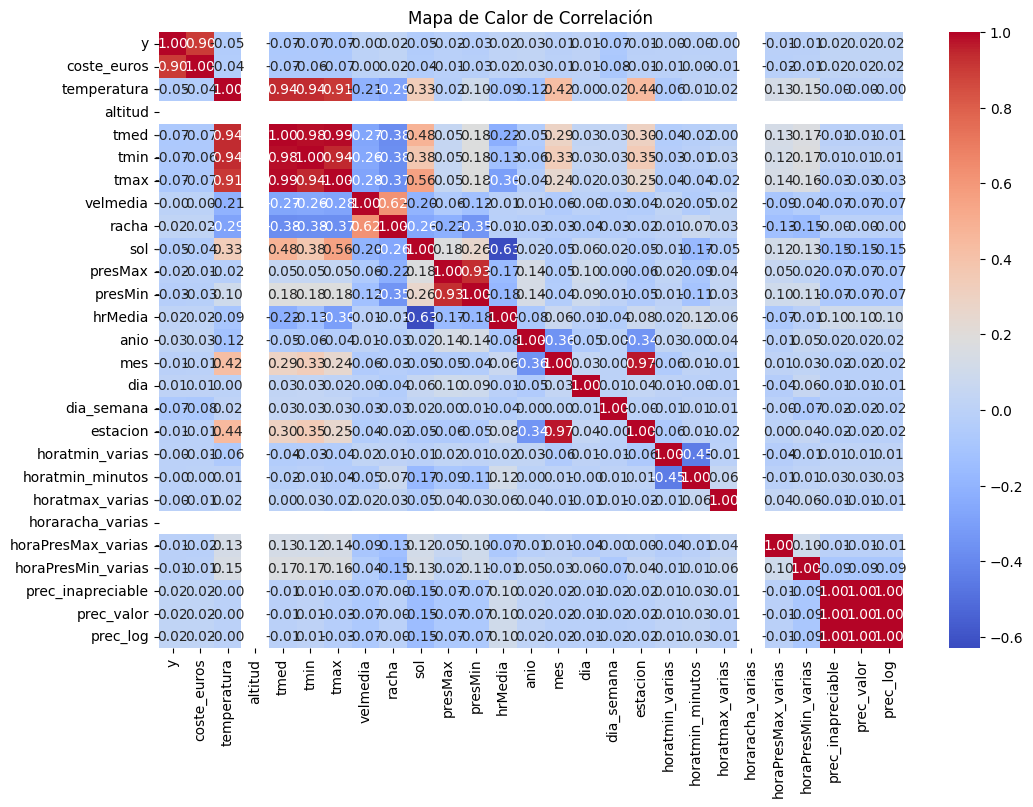

In [ ]:
# Generar un mapa de calor de correlación
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlación')
plt.show()

# Creación del Dataset para el Modelo Prophet
En esta sección, seleccionaremos las variables relevantes y crearemos un nuevo dataset para el modelo Prophet.

In [ ]:
# Seleccionar las variables relevantes
variables_seleccionadas = ['ds', 'y', 'temperatura', 'coste_euros','tmin', 'tmax', 'velmedia','sol','racha','prec_log']

df_seleccionado = df[variables_seleccionadas].copy()

# Enriquecimiento del Dataset con Regresores
En esta sección, agregaremos medias móviles, tendencias, lags, día de la semana, fines de semana y festivos al dataset.

## LAGS

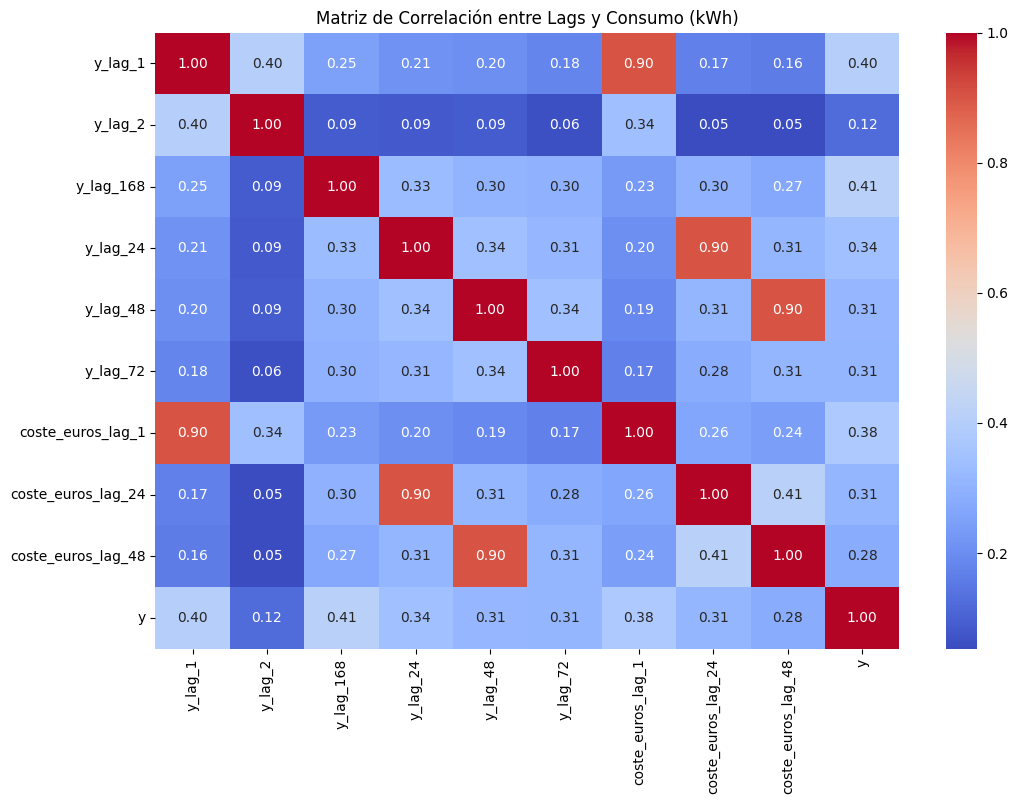

In [ ]:
df_seleccionado['y_lag_1'] = df_seleccionado['y'].shift(1)
df_seleccionado['y_lag_2'] = df_seleccionado['y'].shift(2)

#lag semana pasada en horas
df_seleccionado['y_lag_168'] = df_seleccionado['y'].shift(168)

#lag de 24 horas
df_seleccionado['y_lag_24'] = df_seleccionado['y'].shift(24)
df_seleccionado['y_lag_48'] = df_seleccionado['y'].shift(48)
df_seleccionado['y_lag_72'] = df_seleccionado['y'].shift(72)

# Crear lags para coste_euros
df_seleccionado['coste_euros_lag_1'] = df_seleccionado['coste_euros'].shift(1)
# df_seleccionado['coste_euros_lag_2'] = df_seleccionado['coste_euros'].shift(2)
# df_seleccionado['coste_euros_lag_3'] = df_seleccionado['coste_euros'].shift(3)
df_seleccionado['coste_euros_lag_24'] = df_seleccionado['coste_euros'].shift(24)
df_seleccionado['coste_euros_lag_48'] = df_seleccionado['coste_euros'].shift(48)
lag_columns = [col for col in df_seleccionado.columns if 'lag' in col] + ['y']

#crea una matriz de correlacion entre las variables lags y la variable y
correlation_matrix = df_seleccionado[lag_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Lags y Consumo (kWh)')
plt.show()


## MEDIAS MOVILES Y TREND

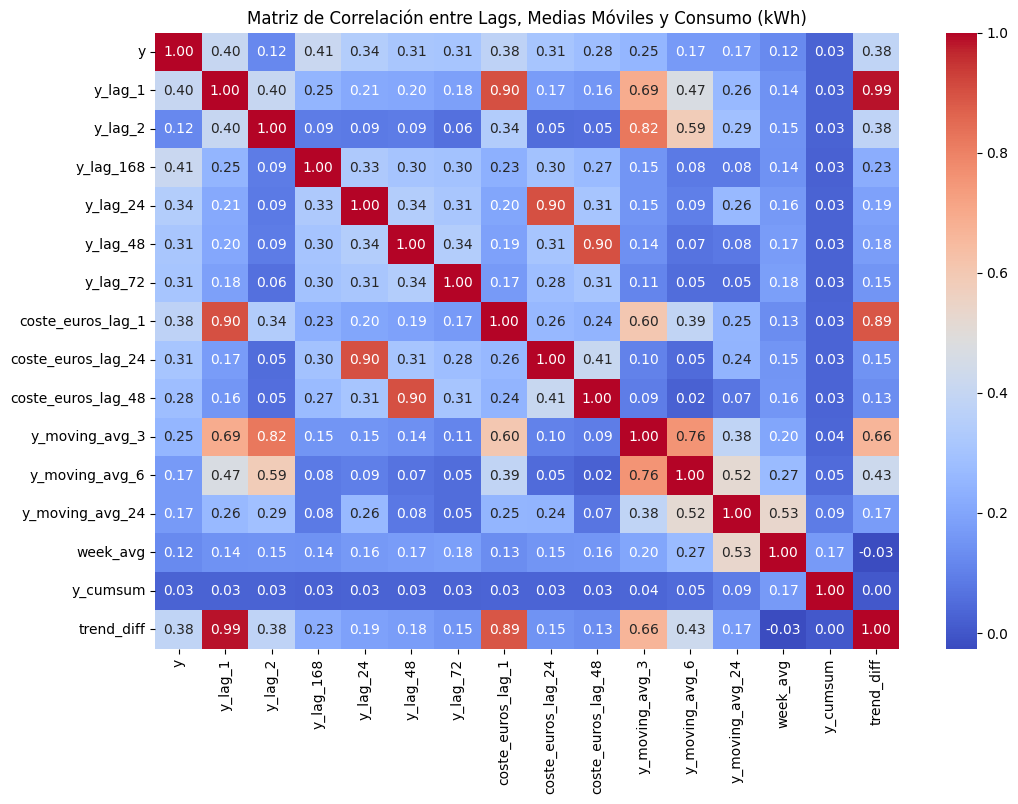

In [ ]:
#generar medias moviles para la variable y
df_seleccionado['y_moving_avg_3'] = df_seleccionado['y'].shift(1).rolling(3).mean()
df_seleccionado['y_moving_avg_6'] = df_seleccionado['y'].shift(1).rolling(6).mean()   
df_seleccionado['y_moving_avg_24'] = df_seleccionado['y'].shift(1).rolling(24).mean()  

df_seleccionado['week_avg'] = df_seleccionado['y'].shift(1).rolling(168).mean()
df_seleccionado['y_cumsum'] = df_seleccionado['y'].shift(1).cumsum()

df_seleccionado['trend_diff'] = df_seleccionado['y'].shift(1) - df_seleccionado['week_avg']

correlation_matrix = df_seleccionado[['y', 'y_lag_1', 'y_lag_2', 'y_lag_168', 'y_lag_24', 'y_lag_48', 'y_lag_72',
                                        'coste_euros_lag_1', 'coste_euros_lag_24', 'coste_euros_lag_48',
                                        'y_moving_avg_3', 'y_moving_avg_6', 'y_moving_avg_24',
                                        'week_avg', 'y_cumsum','trend_diff']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Lags, Medias Móviles y Consumo (kWh)')
plt.show()


## DIAS Y FESTIVOS

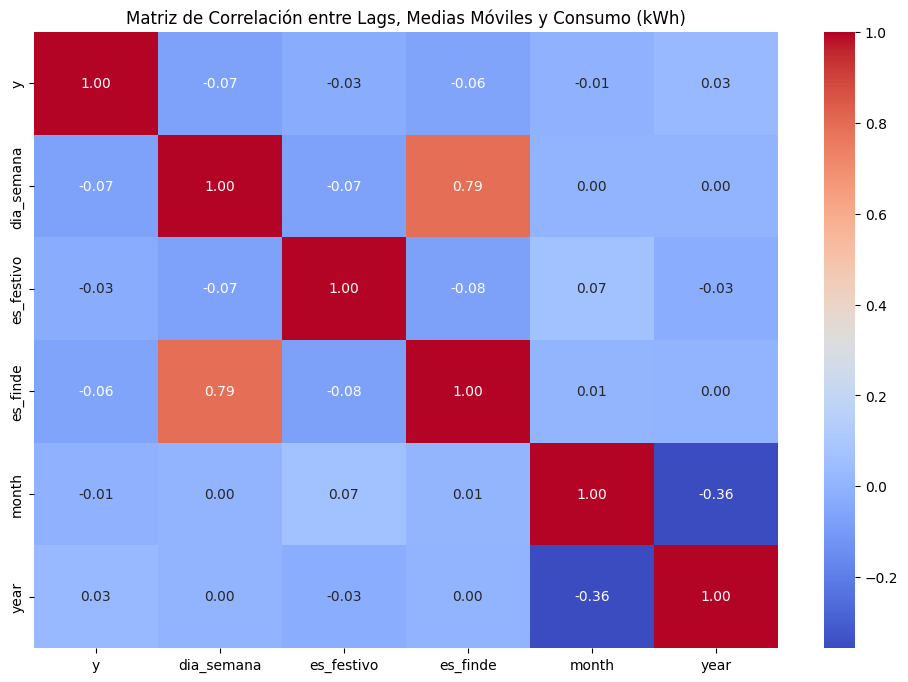

In [ ]:
# Agregar día de la semana y si es fin de semana
df_seleccionado['dia_semana'] = pd.to_datetime(df_seleccionado['ds']).dt.dayofweek
df_seleccionado['es_finde'] = df_seleccionado['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

## agregar festivos de catalunya
catalunya_holidays = holidays.Spain(years=[2017, 2018, 2019, 2020, 2021, 2022, 2023], subdiv='CT')
df_seleccionado['es_festivo'] = df_seleccionado['ds'].apply(lambda x: 1 if pd.to_datetime(x).date() in catalunya_holidays else 0)
# Agregar variables de tendencia y estacionalidad
df_seleccionado['year'] =  pd.to_datetime(df_seleccionado['ds']).dt.year
df_seleccionado['month'] =  pd.to_datetime(df_seleccionado['ds']).dt.month

correlation_matrix = df_seleccionado[['y','dia_semana','es_festivo','es_finde', 'month','year']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Lags, Medias Móviles y Consumo (kWh)')
plt.show()



In [13]:

df_seleccionado.dropna(inplace=True)
df_seleccionado.head()

,ds,y,temperatura,coste_euros,tmin,tmax,velmedia,sol,racha,prec_log,...,y_moving_avg_6,y_moving_avg_24,week_avg,y_cumsum,trend_diff,dia_semana,es_finde,es_festivo,year,month
168,2017-12-18 01:00:00,0.266,11.64,0.039552,4.2,7.0,6.1,0.8,17.5,0.04879,...,0.507000,0.385250,0.380708,63.959,-0.014708,0,0,0,2017,12
169,2017-12-18 02:00:00,0.109,11.58,0.015214,4.2,7.0,6.1,0.8,17.5,0.04879,...,0.474500,0.383125,0.380345,64.225,-0.114345,0,0,0,2017,12
170,2017-12-18 03:00:00,0.105,11.46,0.014152,4.2,7.0,6.1,0.8,17.5,0.04879,...,0.431000,0.381375,0.379923,64.334,-0.270923,0,0,0,2017,12
171,2017-12-18 04:00:00,0.101,11.26,0.014785,4.2,7.0,6.1,0.8,17.5,0.04879,...,0.361167,0.381750,0.379726,64.439,-0.274726,0,0,0,2017,12
172,2017-12-18 05:00:00,0.098,11.07,0.015774,4.2,7.0,6.1,0.8,17.5,0.04879,...,0.245833,0.381792,0.379512,64.540,-0.278512,0,0,0,2017,12


# Modelo Prophet con Cross-Validation
En esta sección, crearemos un modelo Prophet utilizando las variables del dataset, realizaremos un cross-validation y evaluaremos las métricas de rendimiento.

In [14]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [15]:
#save the dataframe to a csv file to the file we are in so we dont need url
df_seleccionado.to_csv("df_seleccionado_5.csv", index=False)

In [16]:
# Cargar el dataset seleccionado
df = pd.read_csv('df_seleccionado_5.csv')
# df['ds'] = pd.to_datetime(df['ds'])

In [17]:

regresores = ['temperatura', 'coste_euros', 'tmin', 'tmax', 'velmedia', 'sol', 'racha', 'prec_log',
             'y_lag_1', 'y_lag_2', 'y_lag_168', 'y_lag_24', 'y_lag_48', 
             'coste_euros_lag_1', 'coste_euros_lag_24', 
             'y_moving_avg_3', 'y_moving_avg_6', 'y_moving_avg_24',
             'week_avg', 'y_cumsum', 'trend_diff', 'dia_semana']



In [ ]:
from itertools import product


param_grid = {                       
    'changepoint_prior_scale': [0.05],
    'seasonality_prior_scale': [3],
    'seasonality_mode': ['additive'],
    'changepoint_range': [0.9],
    'n_changepoints': [10],
}

all_params = [
    dict(zip(param_grid.keys(), v))
    for v in product(*param_grid.values())
]


In [ ]:
results = []            
for params in all_params:
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        **params
    )

    # Re‐gresores
    for reg in regresores:
        m.add_regressor(reg)
    m.add_seasonality('daily',  period=1, fourier_order=15)
    m.add_seasonality('weekly', period=7, fourier_order=10)
    m.add_seasonality('monthly', period=30.5, fourier_order=5)
    m.add_seasonality('yearly', period=365.25, fourier_order=5)

    m.fit(df)

    cv = cross_validation(
        m,
        initial='500 days',
        period='24 hours',
        horizon='24 hours'
    )
    perf = performance_metrics(cv, rolling_window=1)   # media simple
    results.append({
        **params,
        'rmse': perf['rmse'].mean(),
        'mape': perf['mdape'].mean(),
        'mae': perf['mae'].mean(),
        'mse': perf['mse'].mean(),
        'coverage': perf['coverage'].mean()
    })

cv_grid_2 = pd.DataFrame(results).sort_values('rmse')
print(cv_grid_2.head())

15:30:34 - cmdstanpy - INFO - Chain [1] start processing
15:30:36 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/404 [00:00<?, ?it/s]15:30:40 - cmdstanpy - INFO - Chain [1] start processing
15:30:43 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 1/404 [00:03<21:22,  3.18s/it]15:30:43 - cmdstanpy - INFO - Chain [1] start processing
15:30:45 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 2/404 [00:05<17:04,  2.55s/it]15:30:45 - cmdstanpy - INFO - Chain [1] start processing
15:30:48 - cmdstanpy - INFO - Chain [1] done processing
  1%|          | 3/404 [00:08<19:33,  2.93s/it]15:30:49 - cmdstanpy - INFO - Chain [1] start processing
15:30:53 - cmdstanpy - INFO - Chain [1] done processing
  1%|          | 4/404 [00:13<25:29,  3.82s/it]15:30:54 - cmdstanpy - INFO - Chain [1] start processing
15:30:57 - cmdstanpy - INFO - Chain [1] done processing
  1%|          | 5/404 [00:18<26:33,  3.99s/it]15:30:58 - cmdstanpy - INFO - Chain [1] start pr

   changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
0                     0.05                        3         additive   

   changepoint_range  n_changepoints     rmse      mape      mae       mse  \
0                0.9              10  0.07223  0.064076  0.03619  0.005217   

   coverage  
0    0.8977  


In [26]:
cv_grid = pd.DataFrame(results).sort_values('rmse')
print(cv_grid.head())

   changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
0                     0.05                        3         additive   

   changepoint_range  n_changepoints      rmse      mape       mae       mse  \
0                0.9              10  0.141046  0.030124  0.052676  0.019894   

   coverage  
0   0.94269  


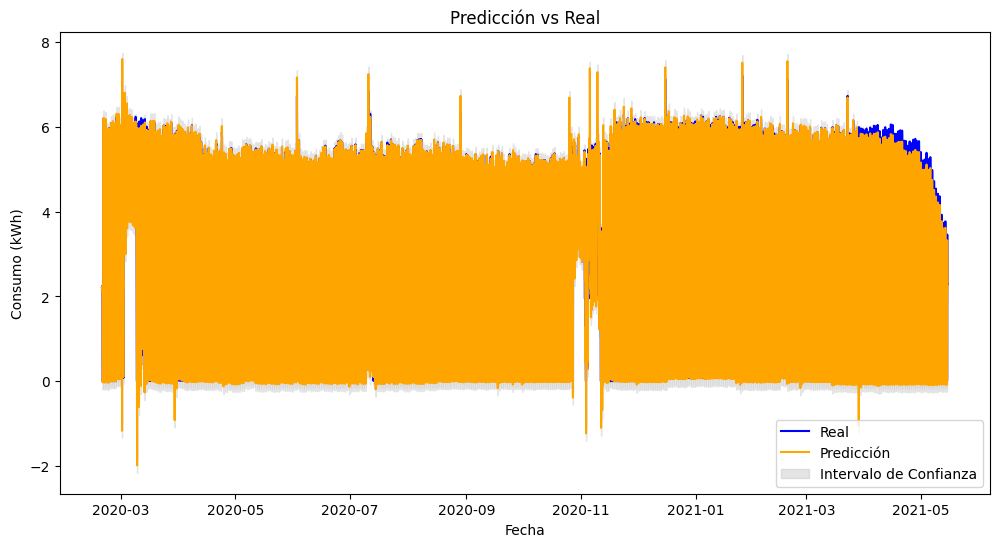

In [27]:
#hazme un grafico de la variable predicada y la real
plt.figure(figsize=(12, 6))
plt.plot(cv['ds'], cv['y'], label='Real', color='blue')
plt.plot(cv['ds'], cv['yhat'], label='Predicción', color='orange')
plt.fill_between(cv['ds'], cv['yhat_lower'], cv['yhat_upper'], color='gray', alpha=0.2, label='Intervalo de Confianza')
plt.title('Predicción vs Real')
plt.xlabel('Fecha')
plt.ylabel('Consumo (kWh)')
plt.legend()
plt.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'browser'

fig = go.Figure()
fig.add_trace(go.Scatter(x=cv['ds'], y=cv['y'], mode='lines', name='Real', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=cv['ds'], y=cv['yhat'], mode='lines', name='Predicción', line=dict(color='orange')))
fig.update_layout(title='Predicción vs Real (Interactividad)',
                  xaxis_title='Fecha',
                  yaxis_title='Consumo (kWh)',
                  legend_title='Leyenda')

In [ ]:

last_3_days = cv[cv['ds'] >= (cv['ds'].max() - pd.Timedelta(days=120))].copy()

fig = go.Figure()
fig.add_trace(go.Scatter(x=last_3_days['ds'], y=last_3_days['y'], mode='lines', name='Real', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=last_3_days['ds'], y=last_3_days['yhat'], mode='lines', name='Predicción', line=dict(color='orange')))
fig.update_layout(title='Predicción vs Real',
                  xaxis_title='Fecha',
                  yaxis_title='Consumo (kWh)',
                  legend_title='Leyenda')
fig.show()
